# Análisis exploratorio de viajes de taxi en Chicago

Este notebook forma parte de **Patrones Lab**, una serie de proyectos donde trabajo datos reales. Acá tomo una base de viajes de taxi reportados en Chicago, reviso su forma general y empiezo a buscar patrones en volumen, duración, distancia, tarifa, velocidad y comportamiento por horario o día.


In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [ ]:
#   import warnings
#   
#   warnings.filterwarnings("ignore")

Defino la carpeta del proyecto para que el notebook encuentre bien las rutas.

In [ ]:
cwd = Path.cwd().resolve()

if cwd.name == "notebooks":
    PROJECT_DIR = cwd.parent
else:
    PROJECT_DIR = cwd

print("Project dir:", PROJECT_DIR.name)
print("Working dir:", cwd.name)

Project dir: 2026-03_taxi-trip-chicago
Working dir: notebooks


Armo las rutas de trabajo para los archivos raw, staging y processed.

In [ ]:
DATA_RAW = PROJECT_DIR / "data" / "raw"
DATA_STAGING = PROJECT_DIR / "data" / "staging"
DATA_PROCESSED = PROJECT_DIR / "data" / "processed"

TRIPS_2026_FILE = DATA_STAGING / "taxi_trips_chicago_2026.csv"
TRIPS_TOTAL_FILE = DATA_STAGING / "taxi_trips_chicago_staging.parquet"

## Carga de la base

Leo la base principal y hago una primera mirada rápida a su tamaño y su contenido.

In [ ]:
df = pd.read_parquet(TRIPS_TOTAL_FILE)
# df = df.sample(frac=0.1, random_state=1990)   # Muestreo

print("trips shape:", df.shape)
df.head()

trips shape: (12662620, 45)


,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,trip_hours,total_calculado,speed_mph,fare_per_mile,trip_total_per_mile,fare_per_minute,trip_total_per_minute,tip_pct,flag_trip_core,time_band
0,0000184e7cd53cee95af32eba49c44e4d20adcd8,f538e6b729d1aaad4230e9dcd9dc2fd9a168826ddadbd6...,2024-01-19 17:00:00,2024-01-19 18:00:00,4051.0,17.12,1.703198e+10,1.703132e+10,76.0,32.0,...,1.125278,59.50,15.214021,2.657710,3.504673,0.673908,0.888669,21.978022,True,afternoon
1,000072ee076c9038868e239ca54185eb43959db0,e51e2c30caec952b40b8329a68b498e18ce8a1f40fa75c...,2024-01-28 14:30:00,2024-01-28 15:00:00,1749.0,12.70,NaN,NaN,6.0,NaN,...,0.485833,33.75,26.140652,2.657480,2.657480,1.157804,1.157804,0.000000,True,afternoon
2,000074019d598c2b1d6e77fbae79e40b0461a2fc,aeb280ef3be3e27e081eb6e76027615b0d40925b84d3eb...,2024-01-05 09:00:00,2024-01-05 09:00:00,517.0,3.39,NaN,NaN,6.0,8.0,...,0.143611,14.69,23.605416,3.218289,4.333333,1.266151,1.704836,25.481210,True,morning
3,00007572c5f92e2ff067e6f838a5ad74e83665d3,7d21c2ca227db8f27dda96612bfe5520ab408fa9a462c8...,2024-01-22 08:45:00,2024-01-22 09:30:00,2050.0,15.06,NaN,NaN,76.0,NaN,...,0.569444,56.06,26.446829,2.606242,3.755644,1.148780,1.655415,28.815287,True,morning
4,00007c3e7546e2c7d15168586943a9c22c3856cf,8ef1056519939d511d24008e394f83e925d2539d668a00...,2024-01-18 19:15:00,2024-01-18 19:30:00,1004.0,1.18,1.703184e+10,1.703184e+10,32.0,32.0,...,0.278889,19.66,4.231076,13.508475,16.661017,0.952590,1.174900,23.337516,True,evening


Separo los viajes de 2026 en una base aparte y dejo el resto para el análisis principal.

In [ ]:
# df queda sólo sin 2026, y se crea uno propio con SÓLO 2026

df_2026 = df[df["trip_year"] == 2026].copy()
df = df[df["trip_year"] != 2026].copy()

In [ ]:
with pd.option_context(
    "display.max_columns", None,
    "display.width", None,
    "display.max_colwidth", None
):
    display(df.head(10))

,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare,tips,tolls,extras,trip_total,payment_type,company,pickup_centroid_latitude,pickup_centroid_longitude,pickup_centroid_location,dropoff_centroid_latitude,dropoff_centroid_longitude,dropoff_centroid_location,trip_date,trip_year,trip_month,trip_day,trip_hour,trip_weekday,trip_weekday_num,is_weekend,flag_monto,flag_pickup_geo,flag_dropoff_geo,trip_minutes,trip_hours,total_calculado,speed_mph,fare_per_mile,trip_total_per_mile,fare_per_minute,trip_total_per_minute,tip_pct,flag_trip_core,time_band
0,0000184e7cd53cee95af32eba49c44e4d20adcd8,f538e6b729d1aaad4230e9dcd9dc2fd9a168826ddadbd67c2f79331875dc586863d73aa3169fb266dc5e5ed6cdc8687537de8071a51556146f5251d4d8e8237f,2024-01-19 17:00:00,2024-01-19 18:00:00,4051.0,17.12,1.703198e+10,1.703132e+10,76.0,32.0,45.50,10.00,0.0,4.0,60.00,Credit Card,Flash Cab,41.979071,-87.903040,POINT (-87.9030396611 41.9790708201),41.884987,-87.620993,POINT (-87.6209929134 41.8849871918),2024-01-19,2024,1,19,17,Friday,4,False,True,True,True,67.516667,1.125278,59.50,15.214021,2.657710,3.504673,0.673908,0.888669,21.978022,True,afternoon
1,000072ee076c9038868e239ca54185eb43959db0,e51e2c30caec952b40b8329a68b498e18ce8a1f40fa75c71e425e9426db562ac617b0a28e1c69f5c579048f75a43a2dc066c17448ab65f5016acca10558df3ed,2024-01-28 14:30:00,2024-01-28 15:00:00,1749.0,12.70,NaN,NaN,6.0,NaN,33.75,0.00,0.0,0.0,33.75,Cash,Flash Cab,41.944227,-87.655998,POINT (-87.6559981815 41.9442266014),NaN,NaN,None,2024-01-28,2024,1,28,14,Sunday,6,True,True,True,False,29.150000,0.485833,33.75,26.140652,2.657480,2.657480,1.157804,1.157804,0.000000,True,afternoon
2,000074019d598c2b1d6e77fbae79e40b0461a2fc,aeb280ef3be3e27e081eb6e76027615b0d40925b84d3eb1301a01293a34c41ec45fe1ff1ceeb0e769565af1573d216d5a6c8bbc260b9f8a8db9be4ef74d31c78,2024-01-05 09:00:00,2024-01-05 09:00:00,517.0,3.39,NaN,NaN,6.0,8.0,10.91,2.78,0.0,1.0,14.69,Mobile,Taxicab Insurance Agency Llc,41.944227,-87.655998,POINT (-87.6559981815 41.9442266014),41.899602,-87.633308,POINT (-87.6333080367 41.899602111),2024-01-05,2024,1,5,9,Friday,4,False,True,True,True,8.616667,0.143611,14.69,23.605416,3.218289,4.333333,1.266151,1.704836,25.481210,True,morning
3,00007572c5f92e2ff067e6f838a5ad74e83665d3,7d21c2ca227db8f27dda96612bfe5520ab408fa9a462c8ca4c73a22c362b8022ac8e0f5538c9b820dc3a6be61e06f215654909a3b02770ddf84631e948479436,2024-01-22 08:45:00,2024-01-22 09:30:00,2050.0,15.06,NaN,NaN,76.0,NaN,39.25,11.31,0.0,5.5,56.56,Credit Card,Globe Taxi,41.980264,-87.913625,POINT (-87.913624596 41.9802643146),NaN,NaN,None,2024-01-22,2024,1,22,8,Monday,0,False,True,True,False,34.166667,0.569444,56.06,26.446829,2.606242,3.755644,1.148780,1.655415,28.815287,True,morning
4,00007c3e7546e2c7d15168586943a9c22c3856cf,8ef1056519939d511d24008e394f83e925d2539d668a002c97c441c1d24ab86e29b31a6d8544356006c1eee49dda811760c872d4ddcbaffd55a681b17864a014,2024-01-18 19:15:00,2024-01-18 19:30:00,1004.0,1.18,1.703184e+10,1.703184e+10,32.0,32.0,15.94,3.72,0.0,0.0,19.66,Mobile,5 Star Taxi,41.880994,-87.632746,POINT (-87.6327464887 41.8809944707),41.880994,-87.632746,POINT (-87.6327464887 41.8809944707),2024-01-18,2024,1,18,19,Thursday,3,False,True,True,True,16.733333,0.278889,19.66,4.231076,13.508475,16.661017,0.952590,1.174900,23.337516,True,evening
5,0000cf293ada965f89a98c8ccfae7b0ce3a03e41,37073e8c9e454886fe4a916f80a9a3478570e7dd3e663f40c5b81eae90f8f611027c67455f43b426f4c34dcb7fdb6697c82a3c6d00237f11a4a6cf5b1d1ce0c7,2024-01-04 07:15:00,2024-01-04 07:30:00,484.0,1.59,1.703128e+10,1.703132e+10,28.0,32.0,7.75,1.24,0.0,0.0,9.49,Mobile,City Service,41.879255,-87.642649,POINT (-87.642648998 41.8792550844),41.884987,-87.620993,POINT (-87.6209929134 41.8849871918),2024-01-04,2024,1,4,7,Thursday,3,False,True,True,True,8.066667,0.134444,8.99,11.826446,4.874214,5.968553,0.960744,1.176446,16.000000,True,morning
6,0001235258d46a21317b6691ade9386c4d7e02c4,715b091e100

## Panel rápido de métricas

Armo un primer panel con volumen, duración, distancia, tarifa y velocidad para tener una referencia general.

In [ ]:
import math
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# base diaria para volumen
daily_trips = df.groupby("trip_date").size()

# KPIs
kpis = [
    {
        "title": "Viajes promedio por día",
        "value": daily_trips.mean(),
        "prefix": "",
        "suffix": " viajes",
        "format": ",.0f"
    },
    {
        "title": "Duración mediana",
        "value": df["trip_minutes"].median(),
        "prefix": "",
        "suffix": " min",
        "format": ",.1f"
    },
    {
        "title": "Distancia mediana",
        "value": df["trip_miles"].median(),
        "prefix": "",
        "suffix": " millas",
        "format": ",.2f"
    },
    {
        "title": "Tarifa mediana",
        "value": df["fare"].median(),
        "prefix": "U$S ",
        "suffix": "",
        "format": ",.2f"
    },
    {
        "title": "Trip total mediano",
        "value": df["trip_total"].median(),
        "prefix": "U$S ",
        "suffix": "",
        "format": ",.2f"
    },
    {
        "title": "Velocidad mediana",
        "value": df["speed_mph"].median(),
        "prefix": "",
        "suffix": " mph",
        "format": ",.1f"
    },
    {
        "title": "% de viajes con propina",
        "value": (df["tips"] > 0).mean() * 100,
        "prefix": "",
        "suffix": "%",
        "format": ",.1f"
    },
    {
        "title": "Propina prom.",
        "value": df["tips"].mean(),
        "prefix": "U$S ",
        "suffix": "",
        "format": ",.2f"
    },
    {
        "title": "% de viajes fin de semana",
        "value": df["is_weekend"].mean() * 100,
        "prefix": "",
        "suffix": "%",
        "format": ",.1f"
    }
]

# layout 3x3
fig = make_subplots(
    rows=3,
    cols=3,
    specs=[
        [{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}],
        [{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}],
        [{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}]
    ],
    vertical_spacing=0.12,
    horizontal_spacing=0.08
)

for i, k in enumerate(kpis):
    row = i // 3 + 1
    col = i % 3 + 1

    fig.add_trace(
        go.Indicator(
            mode="number",
            value=k["value"],
            title={
                "text": k["title"],
                "font": {"size": 16}
            },
            number={
                "prefix": k["prefix"],
                "suffix": k["suffix"],
                "valueformat": k["format"],
                "font": {"size": 42}
            }
        ),
        row=row,
        col=col
    )

fig.update_layout(
    title={
        "text": "KPI principales del dataset de taxi de Chicago",
        "x": 0.5
    },
    template="plotly_white",
    height=750,
    margin=dict(l=30, r=30, t=70, b=30)
)

fig.show()

Completo el panel con métricas monetarias y algunos ratios simples por milla y por minuto.

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# parámetro editable
long_trip_miles = 10

# bases diarias para KPI de volumen monetario
daily_total = df.groupby("trip_date")["trip_total"].sum()
daily_fare = df.groupby("trip_date")["fare"].sum()

# KPIs
kpis = [
    {
        "title": "Recaudación total diaria prom.",
        "value": daily_total.mean(),
        "prefix": "U$S ",
        "suffix": "",
        "format": ",.0f"
    },
    {
        "title": "Tarifa diaria prom.",
        "value": daily_fare.mean(),
        "prefix": "U$S ",
        "suffix": "",
        "format": ",.0f"
    },
    {
        "title": "Tarifa por milla prom.",
        "value": df["fare_per_mile"].mean(),
        "prefix": "U$S ",
        "suffix": " /milla",
        "format": ",.2f"
    },
    {
        "title": "Trip total por milla prom.",
        "value": df["trip_total_per_mile"].mean(),
        "prefix": "U$S ",
        "suffix": " /milla",
        "format": ",.2f"
    },
    {
        "title": "Tarifa por minuto prom.",
        "value": df["fare_per_minute"].mean(),
        "prefix": "U$S ",
        "suffix": " /min",
        "format": ",.2f"
    },
    {
        "title": "Trip total por minuto prom.",
        "value": df["trip_total_per_minute"].mean(),
        "prefix": "U$S ",
        "suffix": " /min",
        "format": ",.2f"
    },
    {
        "title": "% Trip prom.",
        "value": df["tip_pct"].mean(),
        "prefix": "",
        "suffix": "%",
        "format": ",.1f"
    },
    {
        "title": "% de viajes nocturnos",
        "value": (df["time_band"] == "night").mean() * 100,
        "prefix": "",
        "suffix": "%",
        "format": ",.1f"
    },
    {
        "title": f"% de viajes de {long_trip_miles}+ millas",
        "value": (df["trip_miles"] >= long_trip_miles).mean() * 100,
        "prefix": "",
        "suffix": "%",
        "format": ",.1f"
    }
]

fig = make_subplots(
    rows=3,
    cols=3,
    specs=[
        [{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}],
        [{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}],
        [{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}]
    ],
    vertical_spacing=0.12,
    horizontal_spacing=0.08
)

for i, k in enumerate(kpis):
    row = i // 3 + 1
    col = i % 3 + 1

    fig.add_trace(
        go.Indicator(
            mode="number",
            value=k["value"],
            title={
                "text": k["title"],
                "font": {"size": 16}
            },
            number={
                "prefix": k["prefix"],
                "suffix": k["suffix"],
                "valueformat": k["format"],
                "font": {"size": 42}
            }
        ),
        row=row,
        col=col
    )

fig.update_layout(
    title={
        "text": "KPIs operativos y de monetización",
        "x": 0.5
    },
    template="plotly_white",
    height=750,
    margin=dict(l=30, r=30, t=70, b=30)
)

fig.show()

## Volumen de viajes

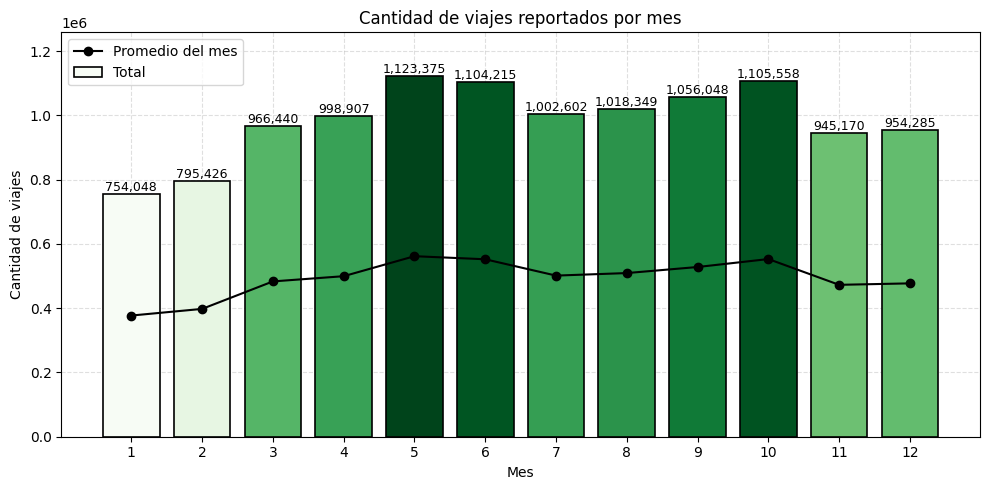

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# total por mes
trips_month_total = (
    df.groupby("trip_month")
    .size()
    .reset_index(name="n_trips_total")
    .sort_values("trip_month")
)

# promedio por mes sobre sus propios años
trips_month_avg = (
    df.groupby(["trip_year", "trip_month"])
    .size()
    .reset_index(name="n_trips")
    .groupby("trip_month")["n_trips"]
    .mean()
    .reset_index(name="n_trips_avg")
    .sort_values("trip_month")
)

# unir total y promedio
trips_month = trips_month_total.merge(trips_month_avg, on="trip_month", how="left")

norm = mcolors.Normalize(
    vmin=trips_month["n_trips_total"].min(),
    vmax=trips_month["n_trips_total"].max()
)

colors = plt.cm.Greens(norm(trips_month["n_trips_total"]))

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    x=trips_month["trip_month"].astype(str),
    height=trips_month["n_trips_total"],
    color=colors,
    edgecolor="black",
    linewidth=1.2,
    label="Total"
)

ax.plot(
    trips_month["trip_month"].astype(str),
    trips_month["n_trips_avg"],
    color="black",
    marker="o",
    linewidth=1.5,
    label="Promedio del mes"
)

ax.set_title("Cantidad de viajes reportados por mes")
ax.set_xlabel("Mes")
ax.set_ylabel("Cantidad de viajes")

ymax = trips_month["n_trips_total"].max()
ax.set_ylim(0, ymax * 1.12)

ax.grid(True, axis="both", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

for bar in bars:
    height = bar.get_height()
    x = bar.get_x() + bar.get_width() / 2
    ax.text(
        x,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
#   pip install seaborn

Comparo cómo se distribuye el volumen diario según el día de la semana.

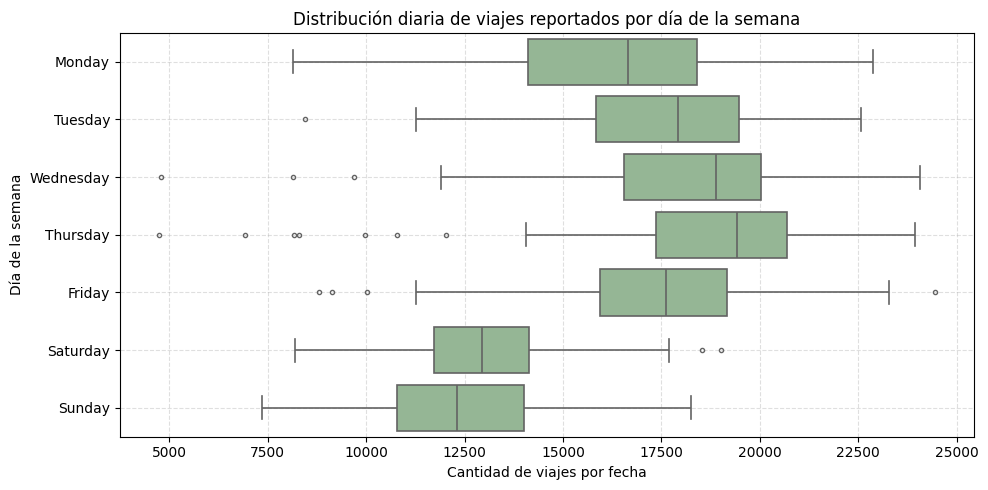

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

trips_date_weekday = (
    df.groupby(["trip_date", "trip_weekday_num", "trip_weekday"])
    .size()
    .reset_index(name="n_trips")
    .sort_values(["trip_weekday_num", "trip_date"])
)

weekday_order = (
    trips_date_weekday
    .sort_values("trip_weekday_num")["trip_weekday"]
    .drop_duplicates()
    .tolist()
)

fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data=trips_date_weekday,
    y="trip_weekday",
    x="n_trips",
    order=weekday_order,
    orient="h",
    color="darkseagreen",
    linewidth=1.2,
    fliersize=3,
    ax=ax
)

ax.set_title("Distribución diaria de viajes reportados por día de la semana")
ax.set_xlabel("Cantidad de viajes por fecha")
ax.set_ylabel("Día de la semana")

ax.grid(True, axis="both", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

Miro el promedio diario por hora y el rango central para ver en qué momentos se concentra más movimiento.

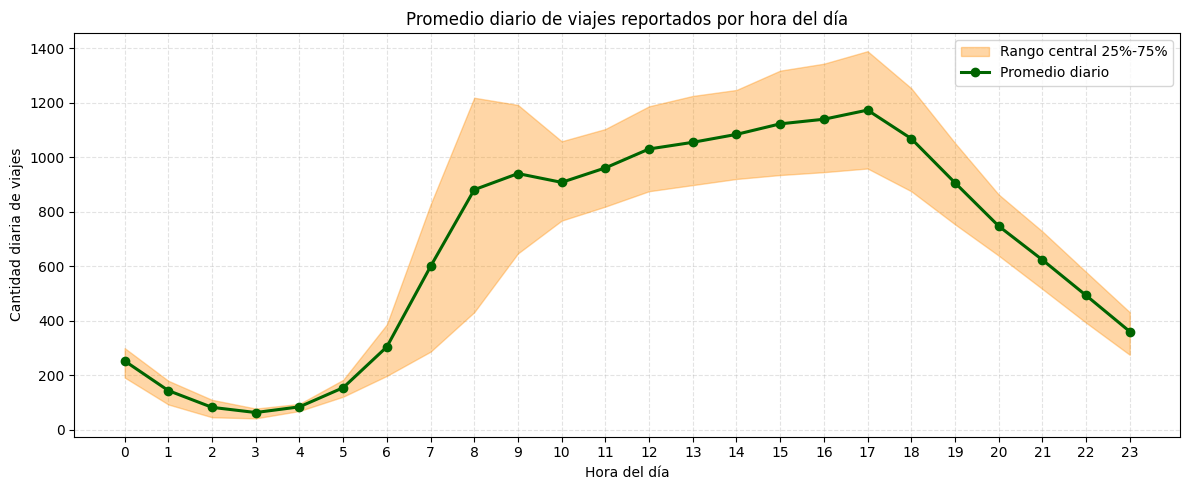

In [ ]:
import matplotlib.pyplot as plt

trips_hour_day = (
    df.groupby(["trip_date", "trip_hour"])
    .size()
    .reset_index(name="n_trips")
)

hour_summary = (
    trips_hour_day.groupby("trip_hour")["n_trips"]
    .agg(
        mean_trips="mean",
        p25=lambda x: x.quantile(0.25),
        p75=lambda x: x.quantile(0.75)
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.fill_between(
    hour_summary["trip_hour"],
    hour_summary["p25"],
    hour_summary["p75"],
    color="darkorange",
    alpha=0.35,
    label="Rango central 25%-75%"
)

ax.plot(
    hour_summary["trip_hour"],
    hour_summary["mean_trips"],
    color="darkgreen",
    linewidth=2.2,
    marker="o",
    label="Promedio diario"
)

ax.set_title("Promedio diario de viajes reportados por hora del día")
ax.set_xlabel("Hora del día")
ax.set_ylabel("Cantidad diaria de viajes")

ax.set_xticks(range(24))
ax.grid(True, axis="both", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

ax.legend()

plt.tight_layout()
plt.show()

## Distribuciones principales

Empiezo por la duración del viaje y marco percentiles para ubicar mejor la cola.

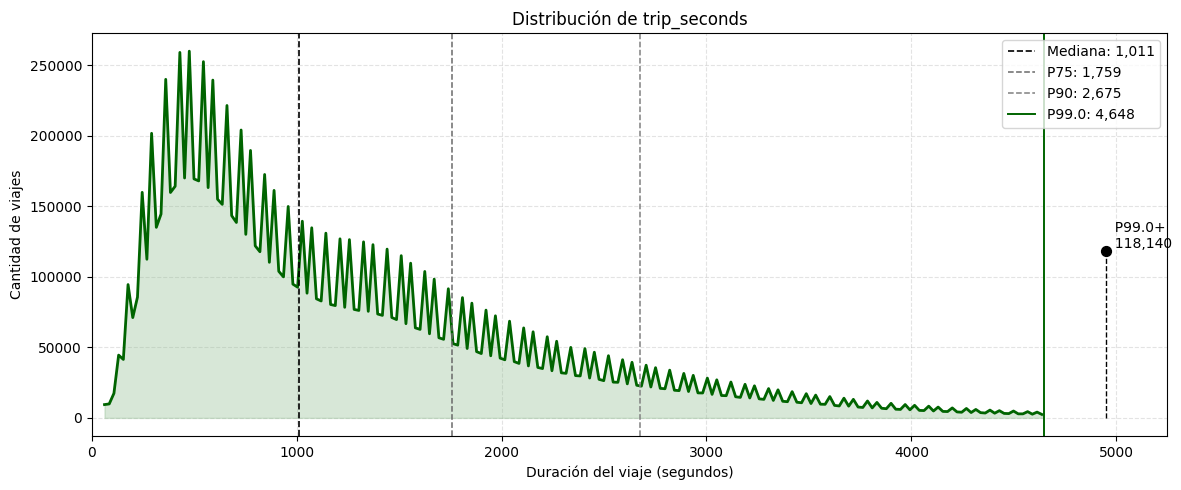

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = df.loc[df["trip_seconds"] >= 50, "trip_seconds"].dropna()

# cambiá esto a mano
bins = 200
tail_q = 0.99
tail_gap = 300

p50 = x.quantile(0.50)
p75 = x.quantile(0.75)
p90 = x.quantile(0.90)
tail_cut = x.quantile(tail_q)

x_core = x[x <= tail_cut]
tail_n = (x > tail_cut).sum()

counts, edges = np.histogram(x_core, bins=bins)
centers = (edges[:-1] + edges[1:]) / 2
x_tail = tail_cut + tail_gap

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(centers, counts, color="darkgreen", linewidth=2)
ax.fill_between(centers, counts, color="darkseagreen", alpha=0.35)

ax.axvline(p50, color="black", linestyle="--", linewidth=1.2, label=f"Mediana: {p50:,.0f}")
ax.axvline(p75, color="dimgray", linestyle="--", linewidth=1.1, label=f"P75: {p75:,.0f}")
ax.axvline(p90, color="gray", linestyle="--", linewidth=1.1, label=f"P90: {p90:,.0f}")
ax.axvline(tail_cut, color="darkgreen", linestyle="-", linewidth=1.4, label=f"P{tail_q*100:.1f}: {tail_cut:,.0f}")

ax.vlines(x_tail, 0, tail_n, color="black", linestyle="--", linewidth=1)
ax.scatter(x_tail, tail_n, color="black", s=50, zorder=3)
ax.text(x_tail, tail_n, f"  P{tail_q*100:.1f}+\n  {tail_n:,.0f}", va="bottom")

ax.set_xlim(0, x_tail + tail_gap)
ax.set_title("Distribución de trip_seconds")
ax.set_xlabel("Duración del viaje (segundos)")
ax.set_ylabel("Cantidad de viajes")

ax.grid(True, axis="both", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)
ax.legend()

plt.tight_layout()
plt.show()

Paso a la distancia y la llevo a una base diaria para ver en qué tramos se apilan más viajes.

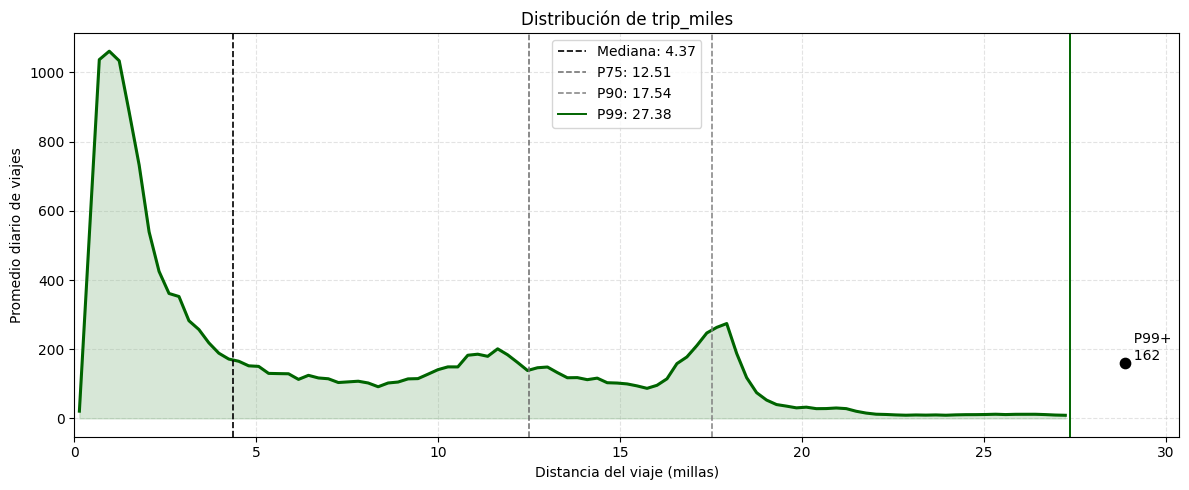

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

x = df.loc[df["trip_miles"].notna(), ["trip_date", "trip_miles"]].copy()
x["trip_date"] = pd.to_datetime(x["trip_date"])

# cambiá esto a mano
bins = 100
tail_q = 0.99
tail_gap = 1.5
min_miles = 0

x = x[x["trip_miles"] >= min_miles].copy()

p50 = x["trip_miles"].quantile(0.50)
p75 = x["trip_miles"].quantile(0.75)
p90 = x["trip_miles"].quantile(0.90)
tail_cut = x["trip_miles"].quantile(tail_q)

edges = np.append(np.linspace(min_miles, tail_cut, bins + 1), np.inf)

x["band"] = pd.cut(
    x["trip_miles"],
    bins=edges,
    include_lowest=True
)

all_dates = np.sort(x["trip_date"].dt.date.unique())
all_bands = x["band"].cat.categories

daily = (
    x.assign(trip_date=x["trip_date"].dt.date)
    .groupby(["trip_date", "band"], observed=False)
    .size()
    .reindex(
        pd.MultiIndex.from_product([all_dates, all_bands], names=["trip_date", "band"]),
        fill_value=0
    )
    .reset_index(name="n_trips")
)

summary = (
    daily.groupby("band", observed=False)["n_trips"]
    .mean()
    .reset_index(name="avg_daily_trips")
)

centers = (edges[:-2] + edges[1:-1]) / 2
x_tail = tail_cut + tail_gap

y_core = summary["avg_daily_trips"].iloc[:-1].to_numpy()
y_tail = summary["avg_daily_trips"].iloc[-1]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(centers, y_core, color="darkgreen", linewidth=2.2)
ax.fill_between(centers, y_core, color="darkseagreen", alpha=0.35)

ax.scatter(x_tail, y_tail, color="black", s=55, zorder=3)
ax.text(x_tail, y_tail, f"  P{tail_q*100:.0f}+\n  {y_tail:,.0f}", va="bottom")

ax.axvline(p50, color="black", linestyle="--", linewidth=1.2, label=f"Mediana: {p50:,.2f}")
ax.axvline(p75, color="dimgray", linestyle="--", linewidth=1.1, label=f"P75: {p75:,.2f}")
ax.axvline(p90, color="gray", linestyle="--", linewidth=1.1, label=f"P90: {p90:,.2f}")
ax.axvline(tail_cut, color="darkgreen", linestyle="-", linewidth=1.4, label=f"P{tail_q*100:.0f}: {tail_cut:,.2f}")

ax.set_xlim(min_miles, x_tail + tail_gap)
ax.set_title("Distribución de trip_miles")
ax.set_xlabel("Distancia del viaje (millas)")
ax.set_ylabel("Promedio diario de viajes")

ax.grid(True, axis="both", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)
ax.legend()

plt.tight_layout()
plt.show()

Reviso la distribución de fare con histograma y boxplot para mirar centro, dispersión y cola alta.

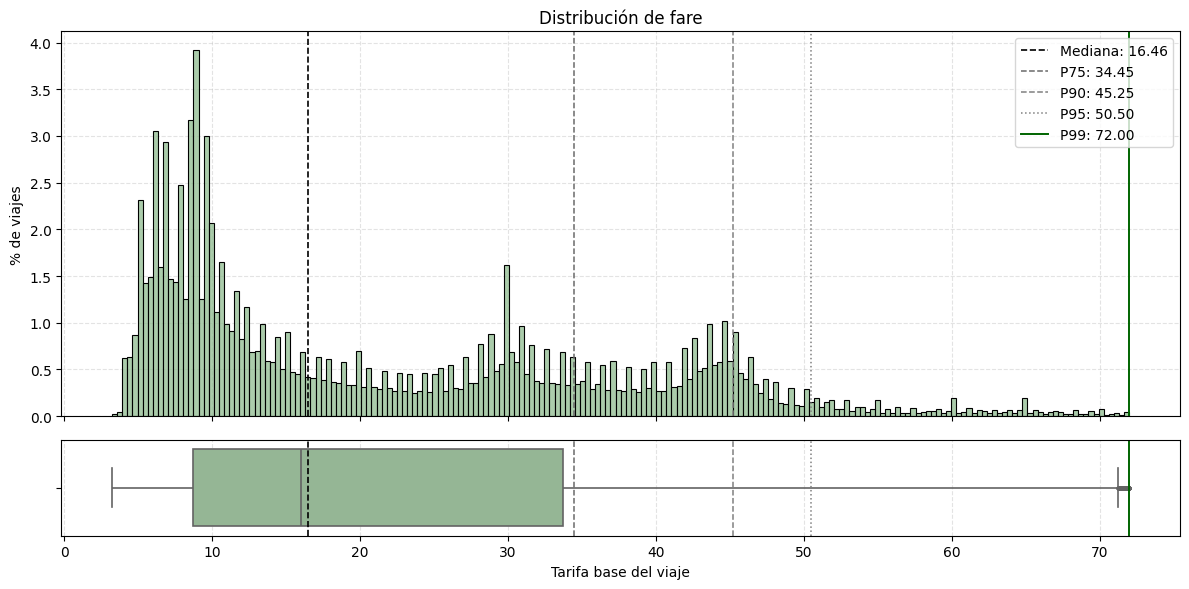

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

x = df["fare"].dropna()

p50 = x.quantile(0.50)
p75 = x.quantile(0.75)
p90 = x.quantile(0.90)
p95 = x.quantile(0.95)
p99 = x.quantile(0.99)

x_plot = x[x <= p99]

fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [4, 1]}
)

# histograma
sns.histplot(
    x=x_plot,
    bins=200,
    stat="percent",
    color="darkseagreen",
    edgecolor="black",
    linewidth=0.8,
    ax=axes[0]
)

axes[0].axvline(p50, color="black", linestyle="--", linewidth=1.2, label=f"Mediana: {p50:,.2f}")
axes[0].axvline(p75, color="dimgray", linestyle="--", linewidth=1.1, label=f"P75: {p75:,.2f}")
axes[0].axvline(p90, color="gray", linestyle="--", linewidth=1.1, label=f"P90: {p90:,.2f}")
axes[0].axvline(p95, color="gray", linestyle=":", linewidth=1.1, label=f"P95: {p95:,.2f}")
axes[0].axvline(p99, color="darkgreen", linestyle="-", linewidth=1.4, label=f"P99: {p99:,.2f}")

axes[0].set_title("Distribución de fare")
axes[0].set_ylabel("% de viajes")
axes[0].grid(True, axis="both", linestyle="--", alpha=0.35)
axes[0].set_axisbelow(True)
axes[0].legend()

# boxplot
sns.boxplot(
    x=x_plot,
    orient="h",
    color="darkseagreen",
    linewidth=1.2,
    fliersize=2,
    ax=axes[1]
)

axes[1].axvline(p50, color="black", linestyle="--", linewidth=1.2)
axes[1].axvline(p75, color="dimgray", linestyle="--", linewidth=1.1)
axes[1].axvline(p90, color="gray", linestyle="--", linewidth=1.1)
axes[1].axvline(p95, color="gray", linestyle=":", linewidth=1.1)
axes[1].axvline(p99, color="darkgreen", linestyle="-", linewidth=1.4)

axes[1].set_xlabel("Tarifa base del viaje")
axes[1].set_ylabel("")
axes[1].grid(True, axis="x", linestyle="--", alpha=0.35)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

Hago lo mismo con trip_total para compararlo con la tarifa.

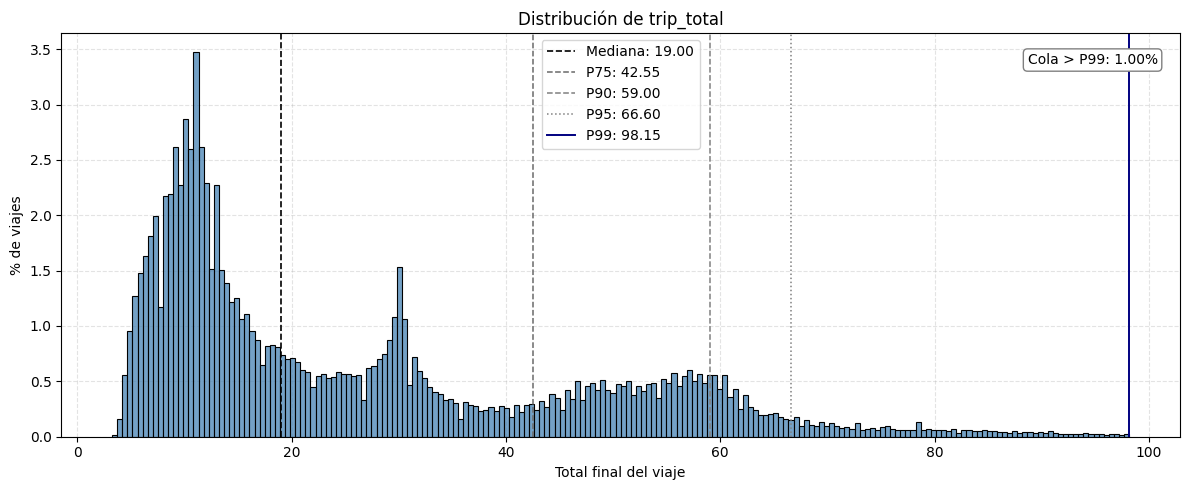

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

x = df.loc[df["trip_total"].notna() & (df["trip_total"] > 0), "trip_total"]

p50 = x.quantile(0.50)
p75 = x.quantile(0.75)
p90 = x.quantile(0.90)
p95 = x.quantile(0.95)
p99 = x.quantile(0.99)

x_plot = x[x <= p99]
tail_pct = (x > p99).mean() * 100

fig, ax = plt.subplots(figsize=(12, 5))

sns.histplot(
    x=x_plot,
    bins=200,
    stat="percent",
    color="steelblue",
    edgecolor="black",
    linewidth=0.8,
    ax=ax
)

ax.axvline(p50, color="black", linestyle="--", linewidth=1.2, label=f"Mediana: {p50:,.2f}")
ax.axvline(p75, color="dimgray", linestyle="--", linewidth=1.1, label=f"P75: {p75:,.2f}")
ax.axvline(p90, color="gray", linestyle="--", linewidth=1.1, label=f"P90: {p90:,.2f}")
ax.axvline(p95, color="gray", linestyle=":", linewidth=1.1, label=f"P95: {p95:,.2f}")
ax.axvline(p99, color="navy", linestyle="-", linewidth=1.4, label=f"P99: {p99:,.2f}")

ax.text(
    0.98, 0.95,
    f"Cola > P99: {tail_pct:.2f}%",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray")
)

ax.set_title("Distribución de trip_total")
ax.set_xlabel("Total final del viaje")
ax.set_ylabel("% de viajes")

ax.grid(True, axis="both", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)
ax.legend()

plt.tight_layout()
plt.show()

## Patrones por horario

Cruzo hora y día de la semana para ver dónde se repite más volumen.

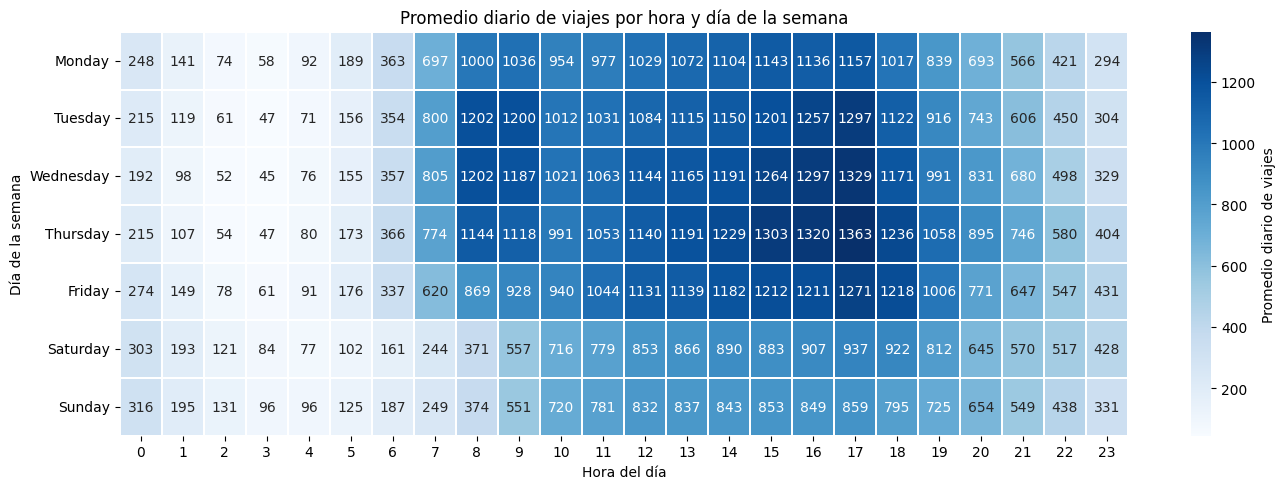

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

hour_weekday = (
    df.groupby(["trip_date", "trip_weekday_num", "trip_weekday", "trip_hour"])
    .size()
    .reset_index(name="n_trips")
)

hour_weekday_avg = (
    hour_weekday.groupby(["trip_weekday_num", "trip_weekday", "trip_hour"])["n_trips"]
    .mean()
    .reset_index(name="avg_daily_trips")
)

heatmap_data = (
    hour_weekday_avg
    .pivot(index="trip_weekday", columns="trip_hour", values="avg_daily_trips")
)

weekday_order = (
    hour_weekday_avg[["trip_weekday_num", "trip_weekday"]]
    .drop_duplicates()
    .sort_values("trip_weekday_num")["trip_weekday"]
    .tolist()
)

heatmap_data = heatmap_data.reindex(weekday_order)

plt.figure(figsize=(14, 5))

sns.heatmap(
    heatmap_data,
    cmap="Blues",
    annot=True,
    fmt=".0f",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Promedio diario de viajes"}
)

plt.title("Promedio diario de viajes por hora y día de la semana")
plt.xlabel("Hora del día")
plt.ylabel("Día de la semana")
plt.tight_layout()
plt.show()

Repito la lógica por empresa y me quedo con las más relevantes para no sobrecargar la vista.

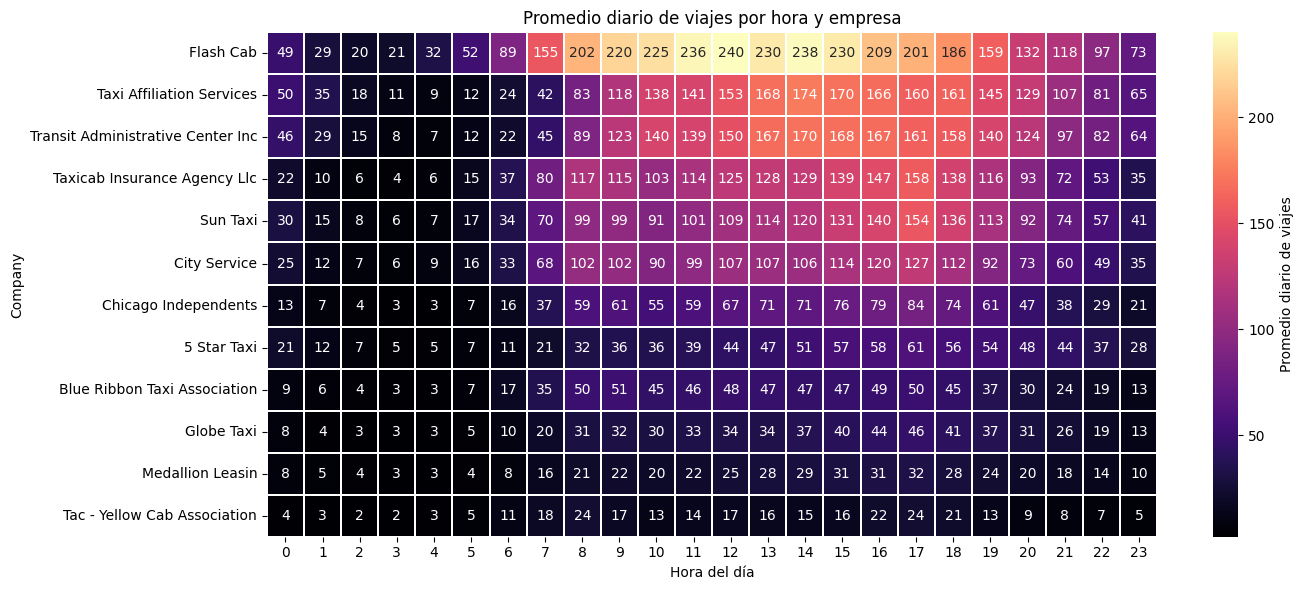

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

hour_company = (
    df.groupby(["trip_date", "trip_hour", "company"])
    .size()
    .reset_index(name="n_trips")
)

hour_company_avg = (
    hour_company.groupby(["trip_hour", "company"])["n_trips"]
    .mean()
    .reset_index(name="avg_daily_trips")
)

top_companies = (
    hour_company_avg.groupby("company")["avg_daily_trips"]
    .sum()
    .sort_values(ascending=False)
    .head(12)
    .index
)

plot_data = hour_company_avg[hour_company_avg["company"].isin(top_companies)].copy()

heatmap_data = (
    plot_data
    .pivot(index="company", columns="trip_hour", values="avg_daily_trips")
    .reindex(index=top_companies, columns=range(24))
)

plt.figure(figsize=(14, 6))

sns.heatmap(
    heatmap_data,
    cmap="magma",
    annot=True,
    fmt=".0f",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Promedio diario de viajes"}
)

plt.title("Promedio diario de viajes por hora y empresa")
plt.xlabel("Hora del día")
plt.ylabel("Company")
plt.tight_layout()
plt.show()

## Relaciones entre variables

Arranco con duración y distancia para ver cómo crecen juntas en la parte central de la base.

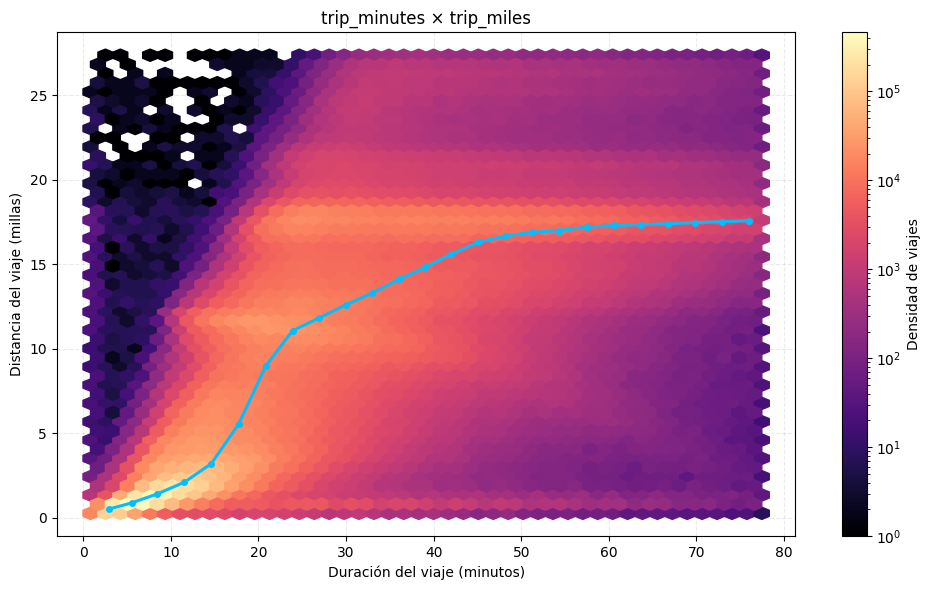

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

plot_df = df[["trip_minutes", "trip_miles"]].dropna().copy()

x_max = plot_df["trip_minutes"].quantile(0.99)
y_max = plot_df["trip_miles"].quantile(0.99)

plot_df = plot_df[
    (plot_df["trip_minutes"] <= x_max) &
    (plot_df["trip_miles"] <= y_max)
]

plot_df["minutes_band"] = pd.cut(plot_df["trip_minutes"], bins=25)

trend = (
    plot_df.groupby("minutes_band", observed=False)
    .agg(
        trip_minutes_med=("trip_minutes", "median"),
        trip_miles_med=("trip_miles", "median")
    )
    .dropna()
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 6))

hb = ax.hexbin(
    plot_df["trip_minutes"],
    plot_df["trip_miles"],
    gridsize=45,
    cmap="magma",
    bins="log",
    mincnt=1
)

ax.plot(
    trend["trip_minutes_med"],
    trend["trip_miles_med"],
    color="deepskyblue",
    linewidth=2.2,
    marker="o",
    markersize=4
)

cb = fig.colorbar(hb, ax=ax)
cb.set_label("Densidad de viajes")

ax.set_title("trip_minutes × trip_miles")
ax.set_xlabel("Duración del viaje (minutos)")
ax.set_ylabel("Distancia del viaje (millas)")

ax.grid(True, linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

Cruzo duración y fare con bandas amplias para ver cómo cambia el rango de precios.

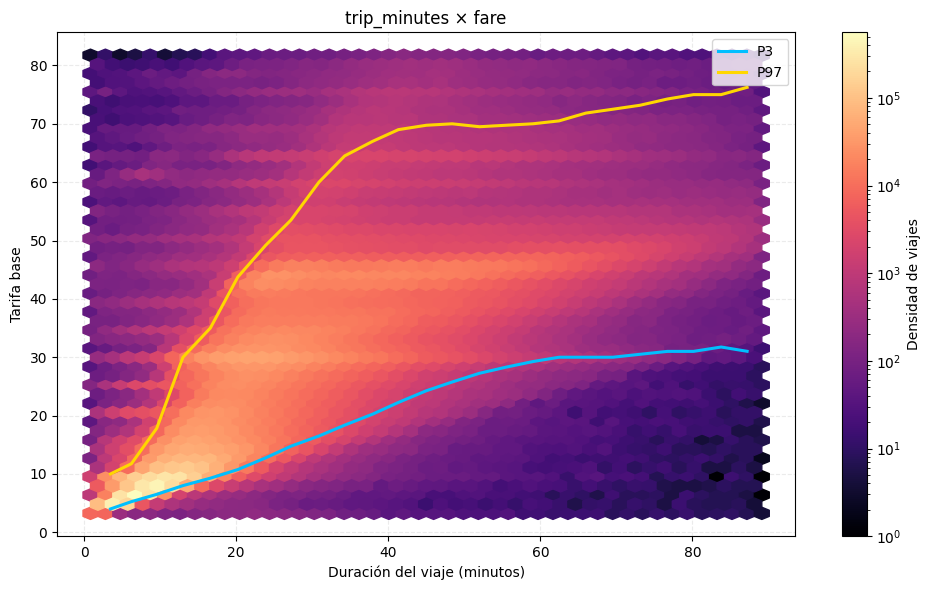

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plot_df = df[["trip_minutes", "fare"]].dropna().copy()

# recorte solo visual
x_max = plot_df["trip_minutes"].quantile(0.995)
y_max = plot_df["fare"].quantile(0.995)

plot_df = plot_df[
    (plot_df["trip_minutes"] <= x_max) &
    (plot_df["fare"] <= y_max)
].copy()

# parámetros para ir ajustando
n_bins = 25
q_low = 0.03
q_high = 0.97

plot_df["minutes_band"] = pd.cut(plot_df["trip_minutes"], bins=n_bins)

band = (
    plot_df.groupby("minutes_band", observed=False)
    .agg(
        x=("trip_minutes", "median"),
        y_low=("fare", lambda s: s.quantile(q_low)),
        y_high=("fare", lambda s: s.quantile(q_high))
    )
    .dropna()
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 6))

hb = ax.hexbin(
    plot_df["trip_minutes"],
    plot_df["fare"],
    gridsize=45,
    cmap="magma",
    bins="log",
    mincnt=1
)

ax.plot(
    band["x"],
    band["y_low"],
    color="deepskyblue",
    linewidth=2.2,
    label=f"P{int(q_low*100)}"
)

ax.plot(
    band["x"],
    band["y_high"],
    color="gold",
    linewidth=2.2,
    label=f"P{int(q_high*100)}"
)

cbar = fig.colorbar(hb, ax=ax)
cbar.set_label("Densidad de viajes")

ax.set_title("trip_minutes × fare")
ax.set_xlabel("Duración del viaje (minutos)")
ax.set_ylabel("Tarifa base")

ax.grid(True, linestyle="--", alpha=0.25)
ax.set_axisbelow(True)
ax.legend()

plt.tight_layout()
plt.show()

Armo una versión más detallada del cruce entre duración y fare usando varios percentiles suavizados.

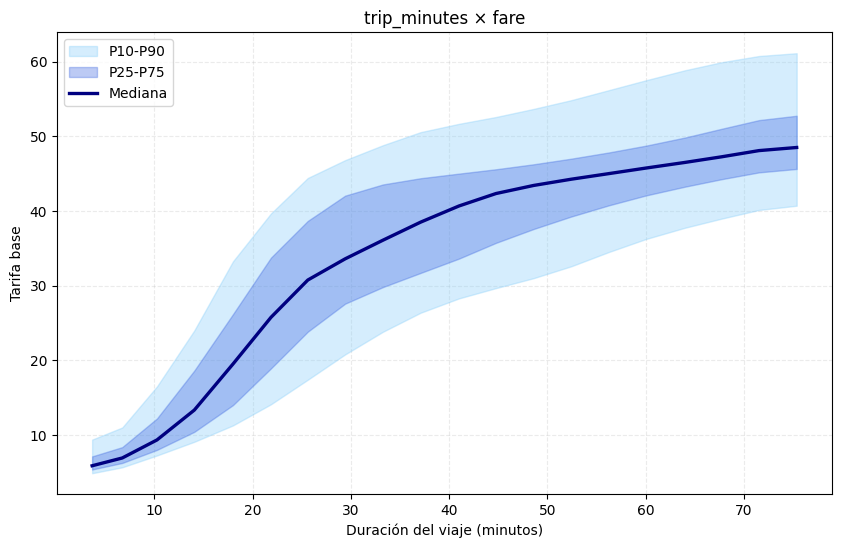

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

plot_df = df[["trip_minutes", "fare"]].dropna().copy()

# recorte solo visual
x_max = plot_df["trip_minutes"].quantile(0.99)
y_max = plot_df["fare"].quantile(0.99)

plot_df = plot_df[
    (plot_df["trip_minutes"] <= x_max) &
    (plot_df["fare"] <= y_max)
].copy()

# parámetro para ajustar
n_bins = 20

plot_df["minutes_band"] = pd.cut(plot_df["trip_minutes"], bins=n_bins)

band = (
    plot_df.groupby("minutes_band", observed=False)
    .agg(
        x=("trip_minutes", "median"),
        p10=("fare", lambda s: s.quantile(0.10)),
        p25=("fare", lambda s: s.quantile(0.25)),
        p50=("fare", "median"),
        p75=("fare", lambda s: s.quantile(0.75)),
        p90=("fare", lambda s: s.quantile(0.90))
    )
    .dropna()
    .reset_index(drop=True)
)

# suavizado opcional
band["p10"] = band["p10"].rolling(3, center=True, min_periods=1).mean()
band["p25"] = band["p25"].rolling(3, center=True, min_periods=1).mean()
band["p50"] = band["p50"].rolling(3, center=True, min_periods=1).mean()
band["p75"] = band["p75"].rolling(3, center=True, min_periods=1).mean()
band["p90"] = band["p90"].rolling(3, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(10, 6))

ax.fill_between(
    band["x"], band["p10"], band["p90"],
    color="lightskyblue", alpha=0.35, label="P10-P90"
)

ax.fill_between(
    band["x"], band["p25"], band["p75"],
    color="royalblue", alpha=0.35, label="P25-P75"
)

ax.plot(
    band["x"], band["p50"],
    color="navy", linewidth=2.4, label="Mediana"
)

ax.set_title("trip_minutes × fare")
ax.set_xlabel("Duración del viaje (minutos)")
ax.set_ylabel("Tarifa base")

ax.grid(True, linestyle="--", alpha=0.25)
ax.set_axisbelow(True)
ax.legend()


plt.show()

## Velocidad observada

Miro cómo cambia la velocidad según la hora del día y marco rangos típicos.

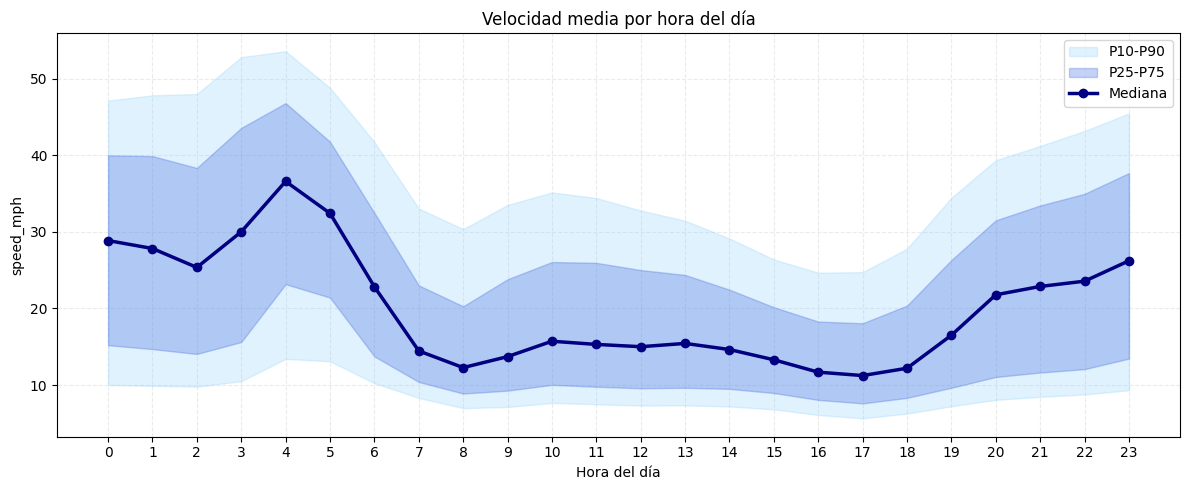

In [ ]:
import matplotlib.pyplot as plt

plot_df = df[["trip_hour", "speed_mph"]].dropna().copy()
plot_df = plot_df[plot_df["speed_mph"] > 0].copy()

hour_speed = (
    plot_df.groupby("trip_hour")["speed_mph"]
    .agg(
        p10=lambda x: x.quantile(0.10),
        p25=lambda x: x.quantile(0.25),
        p50="median",
        p75=lambda x: x.quantile(0.75),
        p90=lambda x: x.quantile(0.90)
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.fill_between(
    hour_speed["trip_hour"],
    hour_speed["p10"],
    hour_speed["p90"],
    color="lightskyblue",
    alpha=0.25,
    label="P10-P90"
)

ax.fill_between(
    hour_speed["trip_hour"],
    hour_speed["p25"],
    hour_speed["p75"],
    color="royalblue",
    alpha=0.30,
    label="P25-P75"
)

ax.plot(
    hour_speed["trip_hour"],
    hour_speed["p50"],
    color="navy",
    linewidth=2.5,
    marker="o",
    label="Mediana"
)

ax.set_title("Velocidad media por hora del día")
ax.set_xlabel("Hora del día")
ax.set_ylabel("speed_mph")

ax.set_xticks(range(24))
ax.grid(True, axis="both", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)
ax.legend()

plt.tight_layout()
plt.show()

Cierro con un mapa de calor de velocidad por hora y día de la semana para detectar los momentos más lentos o más ágiles.

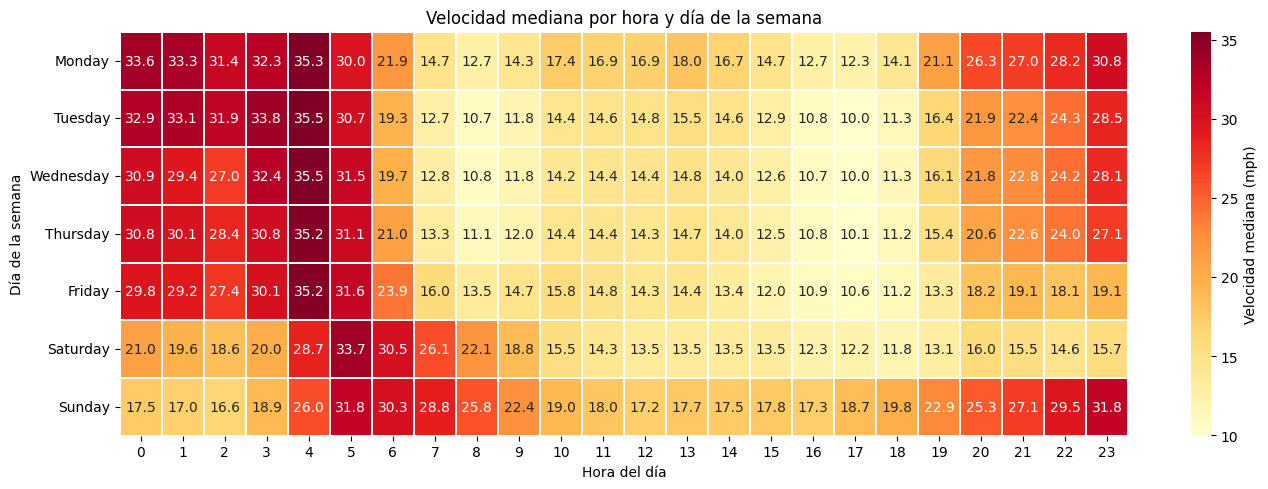

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = df[["trip_weekday_num", "trip_weekday", "trip_hour", "speed_mph"]].dropna().copy()
plot_df = plot_df[plot_df["speed_mph"] > 0].copy()

# recorte solo visual
p99 = plot_df["speed_mph"].quantile(0.99)
plot_df = plot_df[plot_df["speed_mph"] <= p99].copy()

speed_hour_weekday = (
    plot_df.groupby(["trip_weekday_num", "trip_weekday", "trip_hour"])["speed_mph"]
    .median()
    .reset_index(name="median_speed")
)

weekday_order = (
    speed_hour_weekday[["trip_weekday_num", "trip_weekday"]]
    .drop_duplicates()
    .sort_values("trip_weekday_num")["trip_weekday"]
    .tolist()
)

heatmap_data = (
    speed_hour_weekday
    .pivot(index="trip_weekday", columns="trip_hour", values="median_speed")
    .reindex(index=weekday_order, columns=range(24))
)

plt.figure(figsize=(14, 5))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    annot=True,
    fmt=".1f",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Velocidad mediana (mph)"}
)

plt.title("Velocidad mediana por hora y día de la semana")
plt.xlabel("Hora del día")
plt.ylabel("Día de la semana")
plt.tight_layout()
plt.show()